# Análisis de Productividad de Estudiantes

## Objetivo
Predecir el **`productivity_score`** de estudiantes universitarios a partir de variables relacionadas con sus hábitos de estudio, sueño, uso del teléfono y niveles de estrés. Se entrena y compara cuatro modelos de regresión supervisada.

## Dataset
- **Fuente:** Kaggle — Student Productivity & Distraction Dataset (20 000 registros, 18 variables)
- **Archivo:** `student_productivity_distraction_dataset_20000.csv`

## Variables seleccionadas (basadas en correlación de Pearson previa)

| Variable | Descripción |
|---|---|
| `study_hours_per_day` | Horas de estudio diarias |
| `focus_score` | Puntuación de concentración (0-100) |
| `sleep_hours` | Horas de sueño por noche |
| `attendance_percentage` | Porcentaje de asistencia a clases |
| `stress_level` | Nivel de estrés autoreportado |
| `phone_usage_hours` | Horas de uso del teléfono al día |
| **`productivity_score`** | **Variable objetivo** — productividad global del estudiante |

## Imports y configuración global

Importamos todas las librerías necesarias para el análisis: pandas y numpy para manipulación de datos, matplotlib y seaborn para visualización, y scikit-learn para los modelos de machine learning.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Preprocesamiento y división de datos

Dividimos los datos en **dos conjuntos** con la proporción **80/20**:
- **Train (80%):** para entrenar los modelos y compararlos mediante Cross-Validation.
- **Test (20%):** reservado para la evaluación final e imparcial de todos los modelos.

Aplicamos `StandardScaler` entrenado **exclusivamente** sobre el conjunto de train para evitar *data leakage*.

In [9]:
import pandas as pd

# Cargar los datos y definir X e y (añadido para poder ejecutar el notebook de cero)
df = pd.read_csv('student_productivity_distraction_dataset_20000.csv')

feature_cols = [
    'study_hours_per_day',
    'focus_score',
    'sleep_hours',
    'attendance_percentage',
    'stress_level',
    'phone_usage_hours'
]

X = df[feature_cols]
y = df['productivity_score']

print("Datos cargados correctamente. Dimensiones de X:", X.shape)

Datos cargados correctamente. Dimensiones de X: (20000, 6)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Total de muestras : {len(X):,}')
print(f'  Train           : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Test            : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\nEscalado aplicado correctamente (fit solo en train).')
print(f'Media train (escala original) : {X_train.mean().round(3).values}')
print(f'Media train (escalada)        : {X_train_sc.mean(axis=0).round(6)}')

Total de muestras : 20,000
  Train           : 16,000  (80.0%)
  Test            : 4,000  (20.0%)

Escalado aplicado correctamente (fit solo en train).
Media train (escala original) : [ 5.254 64.43   6.515 69.895  5.479  6.259]
Media train (escalada)        : [ 0.  0. -0.  0. -0.  0.]


## Estrategia de Cross-Validation

Usamos **KFold con k=5** aplicado **únicamente al conjunto de train (80%)**. Esto nos da una estimación robusta del rendimiento de cada modelo sin tocar el test.

- El **conjunto de test (20%)** se reserva para la evaluación final comparativa de todos los modelos en la Celda 11.

También definimos la función helper `print_metrics` que calcula y muestra R², RMSE y MAE de forma uniforme.

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def print_metrics(nombre, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'  {nombre}: R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}')
    return {'modelo': nombre, 'R2': r2, 'RMSE': rmse, 'MAE': mae}

print('KFold configurado: 5 folds, shuffle=True, random_state=42')
print('Función print_metrics definida.')

resultados_test = []  # métricas de test de cada modelo
resultados_cv   = []  # métricas CV de cada modelo

KFold configurado: 5 folds, shuffle=True, random_state=42
Función print_metrics definida.


## Modelo 1: Regresión Lineal

La regresión lineal resuelve el problema de forma **analítica** (ecuación normal), no mediante iteraciones. Por tanto, **el early stopping no aplica**: el modelo converge en un único paso, siempre al mismo resultado óptimo.

In [12]:
# ── Entrenamiento ────────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# ── Cross-validation sobre TRAIN ─────────────────────────────────────────────
cv_lr = cross_validate(
    lr, X_train_sc, y_train, cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
    return_train_score=False
)
cv_r2_lr   = cv_lr['test_r2']
cv_rmse_lr = -cv_lr['test_neg_root_mean_squared_error']
cv_mae_lr  = -cv_lr['test_neg_mean_absolute_error']

print('── Regresión Lineal — Cross-Validation (5-fold sobre train) ──')
print(f'  R²   : {cv_r2_lr.mean():.4f} ± {cv_r2_lr.std():.4f}')
print(f'  RMSE : {cv_rmse_lr.mean():.4f} ± {cv_rmse_lr.std():.4f}')
print(f'  MAE  : {cv_mae_lr.mean():.4f} ± {cv_mae_lr.std():.4f}')

resultados_cv.append({
    'Modelo': 'Reg. Lineal',
    'CV R² (mean)': cv_r2_lr.mean(), 'CV R² (std)': cv_r2_lr.std(),
    'CV RMSE (mean)': cv_rmse_lr.mean()
})

# ── Evaluación en TEST ────────────────────────────────────────────────────────
y_test_pred_lr = lr.predict(X_test_sc)
print('\n── Métricas en Test ──')
m_lr = print_metrics('Reg. Lineal', y_test, y_test_pred_lr)
resultados_test.append(m_lr)

── Regresión Lineal — Cross-Validation (5-fold sobre train) ──
  R²   : 1.0000 ± 0.0000
  RMSE : 0.0029 ± 0.0000
  MAE  : 0.0025 ± 0.0000

── Métricas en Test ──
  Reg. Lineal: R²=1.0000 | RMSE=0.0029 | MAE=0.0025


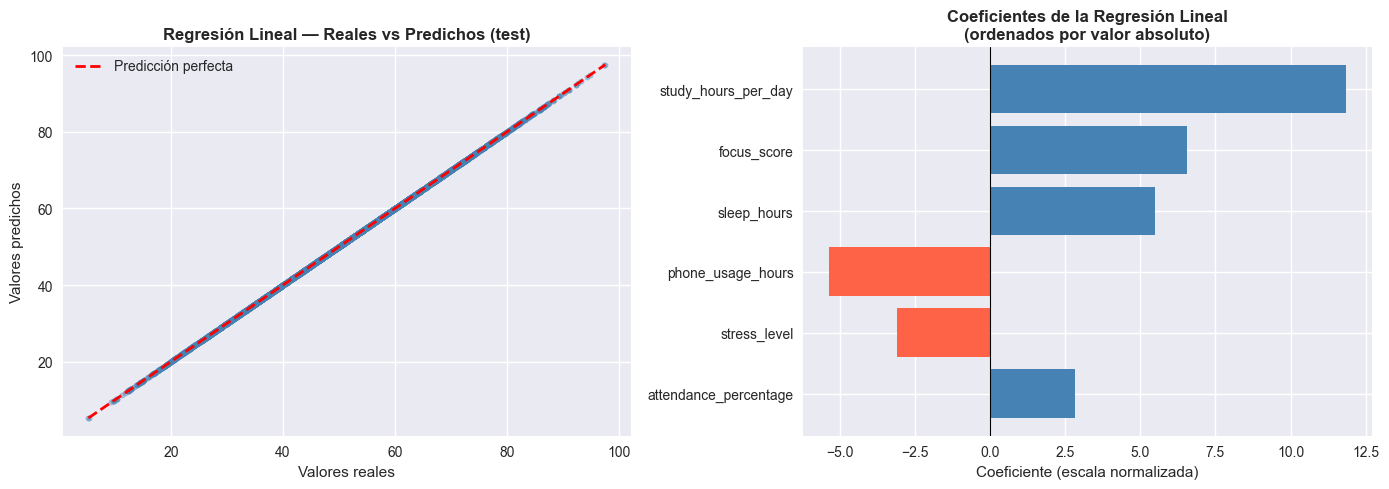


Tabla de coeficientes (mayor impacto primero):


,Feature,Coeficiente
0,study_hours_per_day,11.843252
1,focus_score,6.547794
2,sleep_hours,5.486395
3,phone_usage_hours,-5.350638
4,stress_level,-3.094508
5,attendance_percentage,2.817743


In [13]:
# ── Gráfico: reales vs predichos (test set) ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_test_pred_lr, alpha=0.4, color='steelblue', s=15)
lims = [min(y_test.min(), y_test_pred_lr.min()), max(y_test.max(), y_test_pred_lr.max())]
ax1.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax1.set_xlabel('Valores reales', fontsize=11)
ax1.set_ylabel('Valores predichos', fontsize=11)
ax1.set_title('Regresión Lineal — Reales vs Predichos (test)', fontsize=12, fontweight='bold')
ax1.legend()

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=True)

colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coeficiente']]
ax2.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Coeficiente (escala normalizada)', fontsize=11)
ax2.set_title('Coeficientes de la Regresión Lineal\n(ordenados por valor absoluto)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nTabla de coeficientes (mayor impacto primero):')
display(coef_df.sort_values('Coeficiente', key=abs, ascending=False).reset_index(drop=True))

## Modelo 2: Árbol de Decisión

El árbol se construye en **un único recorrido top-down**, no de forma iterativa. El early stopping clásico no aplica. En su lugar usamos **parada anticipada por criterio de pureza**: `min_impurity_decrease=0.001` evita que el árbol siga dividiendo nodos cuando la ganancia de información es mínima, lo que equivale a un mecanismo de poda preventiva.

In [14]:
# ── Entrenamiento con parada por pureza mínima ───────────────────────────────
dt = DecisionTreeRegressor(
    max_depth=5,
    min_impurity_decrease=0.001,  # no dividir si la ganancia < 0.001
    min_samples_leaf=10,           # nodo hoja requiere al menos 10 muestras
    random_state=42
)
dt.fit(X_train_sc, y_train)
print(f'Profundidad real del árbol : {dt.get_depth()}  (máx. permitido: 5)')
print(f'Número de hojas            : {dt.get_n_leaves()}')

# ── Cross-validation sobre TRAIN ─────────────────────────────────────────────
cv_dt = cross_validate(
    dt, X_train_sc, y_train, cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']
)
cv_r2_dt   = cv_dt['test_r2']
cv_rmse_dt = -cv_dt['test_neg_root_mean_squared_error']
cv_mae_dt  = -cv_dt['test_neg_mean_absolute_error']

print('\n── Árbol de Decisión — Cross-Validation (5-fold sobre train) ──')
print(f'  R²   : {cv_r2_dt.mean():.4f} ± {cv_r2_dt.std():.4f}')
print(f'  RMSE : {cv_rmse_dt.mean():.4f} ± {cv_rmse_dt.std():.4f}')
print(f'  MAE  : {cv_mae_dt.mean():.4f} ± {cv_mae_dt.std():.4f}')

resultados_cv.append({
    'Modelo': 'Árbol Decisión',
    'CV R² (mean)': cv_r2_dt.mean(), 'CV R² (std)': cv_r2_dt.std(),
    'CV RMSE (mean)': cv_rmse_dt.mean()
})

# ── Evaluación en TEST ────────────────────────────────────────────────────────
y_test_pred_dt = dt.predict(X_test_sc)
print('\n── Métricas en Test ──')
m_dt = print_metrics('Árbol Decisión', y_test, y_test_pred_dt)
resultados_test.append(m_dt)

print('\n── Primeras 3 niveles del árbol ──')
print(export_text(dt, feature_names=feature_cols, max_depth=3))

Profundidad real del árbol : 5  (máx. permitido: 5)
Número de hojas            : 32

── Árbol de Decisión — Cross-Validation (5-fold sobre train) ──
  R²   : 0.7921 ± 0.0036
  RMSE : 7.3352 ± 0.0723
  MAE  : 5.9160 ± 0.0643

── Métricas en Test ──
  Árbol Decisión: R²=0.7948 | RMSE=7.2698 | MAE=5.8397

── Primeras 3 niveles del árbol ──
|--- study_hours_per_day <= -0.03
|   |--- focus_score <= -0.05
|   |   |--- study_hours_per_day <= -0.91
|   |   |   |--- phone_usage_hours <= 0.10
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- phone_usage_hours >  0.10
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- study_hours_per_day >  -0.91
|   |   |   |--- sleep_hours <= 0.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- sleep_hours >  0.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- focus_score >  -0.05
|   |   |--- study_hours_per_day <= -0.83
|   |   |   |--- phone_usage_hours <= 0.12
|   |   |   |   |--- truncated branch of d

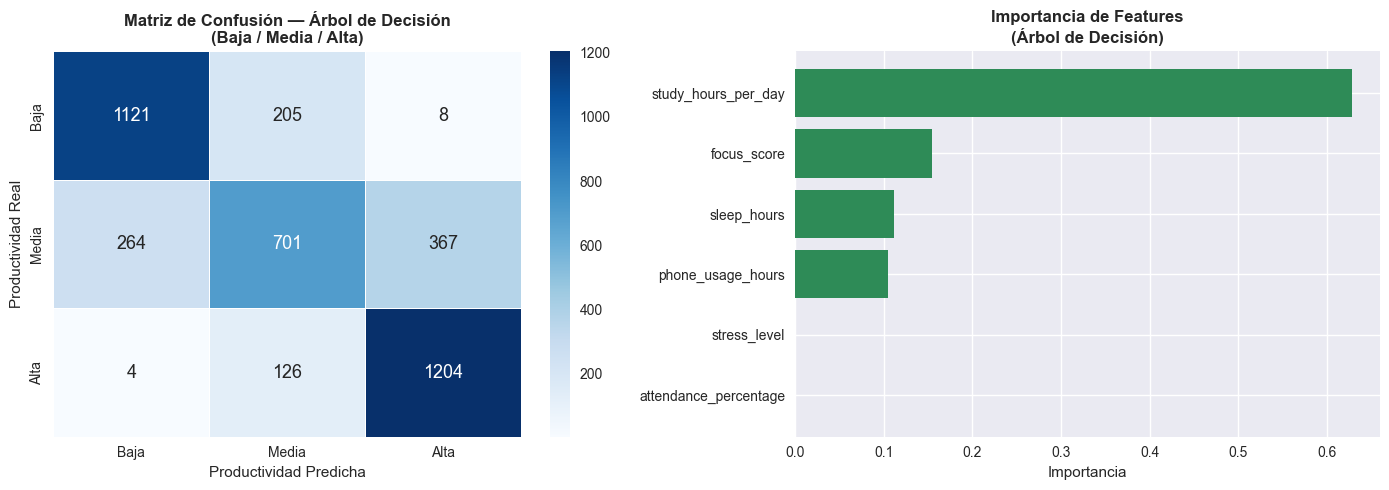

Exactitud global (3 niveles): 0.7565

Distribución real en test:
productivity_score
Baja     1334
Media    1332
Alta     1334
Name: count, dtype: int64


In [15]:
from sklearn.metrics import confusion_matrix

# ── Matriz de confusión + feature importance ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Discretizamos el target en 3 niveles usando terciles del test set
_, bin_edges = pd.qcut(y_test, q=3, retbins=True)
bin_edges[0]  -= 0.01
bin_edges[-1] += 0.01
etiquetas = ['Baja', 'Media', 'Alta']

y_test_bins    = pd.cut(y_test,         bins=bin_edges, labels=etiquetas)
y_pred_dt_bins = pd.cut(y_test_pred_dt, bins=bin_edges, labels=etiquetas)

cm = confusion_matrix(y_test_bins, y_pred_dt_bins, labels=etiquetas)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=etiquetas, yticklabels=etiquetas,
    linewidths=0.5, ax=ax1, annot_kws={'size': 13}
)
ax1.set_xlabel('Productividad Predicha', fontsize=11)
ax1.set_ylabel('Productividad Real', fontsize=11)
ax1.set_title('Matriz de Confusión — Árbol de Decisión\n(Baja / Media / Alta)',
              fontsize=12, fontweight='bold')

fi_dt = pd.Series(dt.feature_importances_, index=feature_cols).sort_values()
ax2.barh(fi_dt.index, fi_dt.values, color='seagreen')
ax2.set_xlabel('Importancia', fontsize=11)
ax2.set_title('Importancia de Features\n(Árbol de Decisión)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

acc = cm.diagonal().sum() / cm.sum()
print(f'Exactitud global (3 niveles): {acc:.4f}')
print('\nDistribución real en test:')
print(y_test_bins.value_counts().sort_index())

## Modelo 3: Random Forest

Random Forest no tiene early stopping nativo en sklearn (los árboles se construyen de forma independiente, no secuencial). Lo implementamos **manualmente** con `warm_start=True` y el **OOB score** (Out-Of-Bag): en cada ronda añadimos 10 árboles y paramos si el OOB R² no mejora en 5 rondas consecutivas (`patience=5`).

Early stopping: sin mejora en 5 rondas consecutivas.
Árboles utilizados : 380  (máx. posible: 400)
Mejor OOB R²       : 0.9830


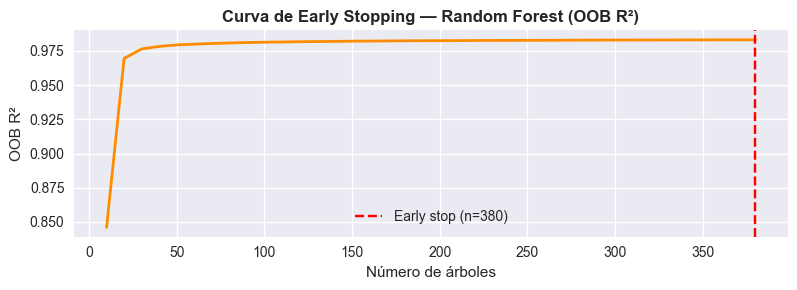


── Random Forest — Cross-Validation (5-fold sobre train) ──
  R²   : 0.9813 ± 0.0008
  RMSE : 2.2019 ± 0.0466
  MAE  : 1.7411 ± 0.0305

── Métricas en Test ──
  Random Forest: R²=0.9830 | RMSE=2.0940 | MAE=1.6382


In [16]:
# ── Early stopping manual con warm_start + OOB score ─────────────────────────
rf = RandomForestRegressor(
    n_estimators=10, random_state=42, n_jobs=-1,
    warm_start=True, oob_score=True
)

oob_scores, n_trees_log = [], []
best_oob, patience, no_improve = -np.inf, 5, 0

for n in range(10, 401, 10):
    rf.n_estimators = n
    rf.fit(X_train_sc, y_train)
    oob = rf.oob_score_
    oob_scores.append(oob)
    n_trees_log.append(n)
    if oob > best_oob + 1e-4:
        best_oob = oob
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping: sin mejora en {patience} rondas consecutivas.')
            break

print(f'Árboles utilizados : {rf.n_estimators}  (máx. posible: 400)')
print(f'Mejor OOB R²       : {best_oob:.4f}')

# Gráfico de la curva OOB
fig_oob, ax_oob = plt.subplots(figsize=(8, 3))
ax_oob.plot(n_trees_log, oob_scores, color='darkorange', linewidth=2)
ax_oob.axvline(rf.n_estimators, color='red', linestyle='--', label=f'Early stop (n={rf.n_estimators})')
ax_oob.set_xlabel('Número de árboles')
ax_oob.set_ylabel('OOB R²')
ax_oob.set_title('Curva de Early Stopping — Random Forest (OOB R²)', fontweight='bold')
ax_oob.legend()
plt.tight_layout()
plt.show()

# ── Cross-validation sobre TRAIN ─────────────────────────────────────────────
cv_rf = cross_validate(
    rf, X_train_sc, y_train, cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
    n_jobs=-1
)
cv_r2_rf   = cv_rf['test_r2']
cv_rmse_rf = -cv_rf['test_neg_root_mean_squared_error']
cv_mae_rf  = -cv_rf['test_neg_mean_absolute_error']

print('\n── Random Forest — Cross-Validation (5-fold sobre train) ──')
print(f'  R²   : {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}')
print(f'  RMSE : {cv_rmse_rf.mean():.4f} ± {cv_rmse_rf.std():.4f}')
print(f'  MAE  : {cv_mae_rf.mean():.4f} ± {cv_mae_rf.std():.4f}')

resultados_cv.append({
    'Modelo': 'Random Forest',
    'CV R² (mean)': cv_r2_rf.mean(), 'CV R² (std)': cv_r2_rf.std(),
    'CV RMSE (mean)': cv_rmse_rf.mean()
})

# ── Evaluación en TEST ────────────────────────────────────────────────────────
y_test_pred_rf = rf.predict(X_test_sc)
print('\n── Métricas en Test ──')
m_rf = print_metrics('Random Forest', y_test, y_test_pred_rf)
resultados_test.append(m_rf)

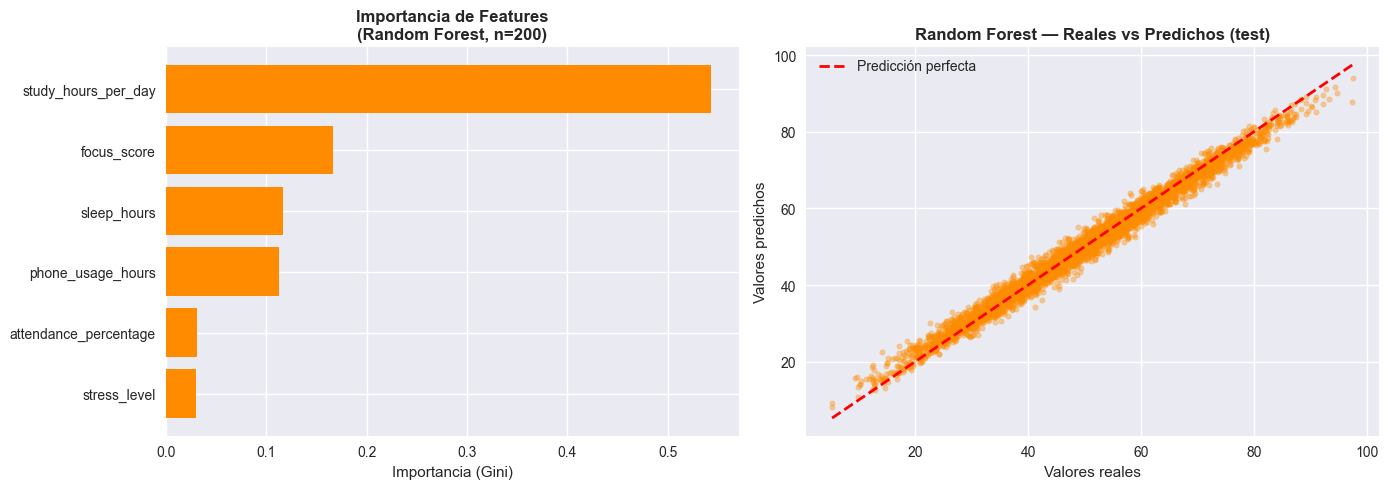

In [17]:
# ── Gráfico: feature importance + reales vs predichos (test) ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fi_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
ax1.barh(fi_rf.index, fi_rf.values, color='darkorange')
ax1.set_xlabel('Importancia (Gini)', fontsize=11)
ax1.set_title('Importancia de Features\n(Random Forest, n=200)', fontsize=12, fontweight='bold')

ax2.scatter(y_test, y_test_pred_rf, alpha=0.4, color='darkorange', s=15)
lims = [min(y_test.min(), y_test_pred_rf.min()), max(y_test.max(), y_test_pred_rf.max())]
ax2.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax2.set_xlabel('Valores reales', fontsize=11)
ax2.set_ylabel('Valores predichos', fontsize=11)
ax2.set_title('Random Forest — Reales vs Predichos (test)', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## Modelo 4: Gradient Boosting (GBT)

Gradient Boosting tiene **early stopping nativo** en sklearn mediante `n_iter_no_change`: si el error en un subconjunto de validación interno (`validation_fraction=0.1`) no mejora en 15 rondas consecutivas, el entrenamiento se detiene antes de llegar al máximo de estimadores. Esto previene el sobreajuste y ahorra tiempo de cómputo.

Árboles usados (early stopping) : 500 de 500 máx.


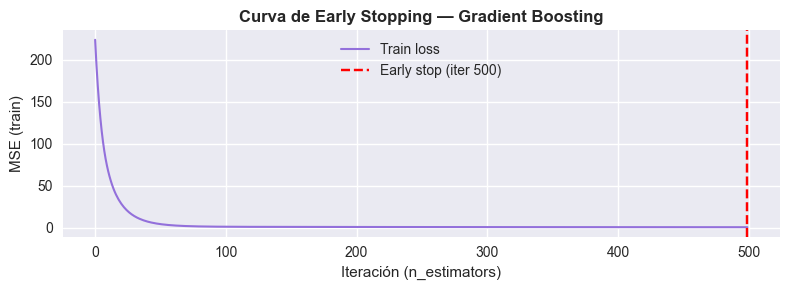


── Gradient Boosting — Cross-Validation (5-fold sobre train) ──
  R²   : 0.9968 ± 0.0001
  RMSE : 0.9111 ± 0.0147
  MAE  : 0.7263 ± 0.0126

── Métricas en Test ──
  Gradient Boosting: R²=0.9970 | RMSE=0.8789 | MAE=0.6938


In [18]:
# ── Entrenamiento con early stopping nativo ───────────────────────────────────
gbt = GradientBoostingRegressor(
    n_estimators=500,           # máximo; early stopping lo reducirá
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    n_iter_no_change=15,        # para si no mejora en 15 iteraciones seguidas
    validation_fraction=0.1,    # 10% del train para monitorizar el early stop
    tol=1e-4
)
gbt.fit(X_train_sc, y_train)
print(f'Árboles usados (early stopping) : {gbt.n_estimators_} de {gbt.n_estimators} máx.')

# Curva de entrenamiento (train loss por iteración)
fig_es, ax_es = plt.subplots(figsize=(8, 3))
ax_es.plot(gbt.train_score_, color='mediumpurple', linewidth=1.5, label='Train loss')
ax_es.axvline(gbt.n_estimators_ - 1, color='red', linestyle='--',
              label=f'Early stop (iter {gbt.n_estimators_})')
ax_es.set_xlabel('Iteración (n_estimators)')
ax_es.set_ylabel('MSE (train)')
ax_es.set_title('Curva de Early Stopping — Gradient Boosting', fontweight='bold')
ax_es.legend()
plt.tight_layout()
plt.show()

# ── Cross-validation sobre TRAIN ─────────────────────────────────────────────
cv_gbt = cross_validate(
    gbt, X_train_sc, y_train, cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']
)
cv_r2_gbt   = cv_gbt['test_r2']
cv_rmse_gbt = -cv_gbt['test_neg_root_mean_squared_error']
cv_mae_gbt  = -cv_gbt['test_neg_mean_absolute_error']

print('\n── Gradient Boosting — Cross-Validation (5-fold sobre train) ──')
print(f'  R²   : {cv_r2_gbt.mean():.4f} ± {cv_r2_gbt.std():.4f}')
print(f'  RMSE : {cv_rmse_gbt.mean():.4f} ± {cv_rmse_gbt.std():.4f}')
print(f'  MAE  : {cv_mae_gbt.mean():.4f} ± {cv_mae_gbt.std():.4f}')

resultados_cv.append({
    'Modelo': 'Gradient Boosting',
    'CV R² (mean)': cv_r2_gbt.mean(), 'CV R² (std)': cv_r2_gbt.std(),
    'CV RMSE (mean)': cv_rmse_gbt.mean()
})

# ── Evaluación en TEST ────────────────────────────────────────────────────────
y_test_pred_gbt = gbt.predict(X_test_sc)
print('\n── Métricas en Test ──')
m_gbt = print_metrics('Gradient Boosting', y_test, y_test_pred_gbt)
resultados_test.append(m_gbt)

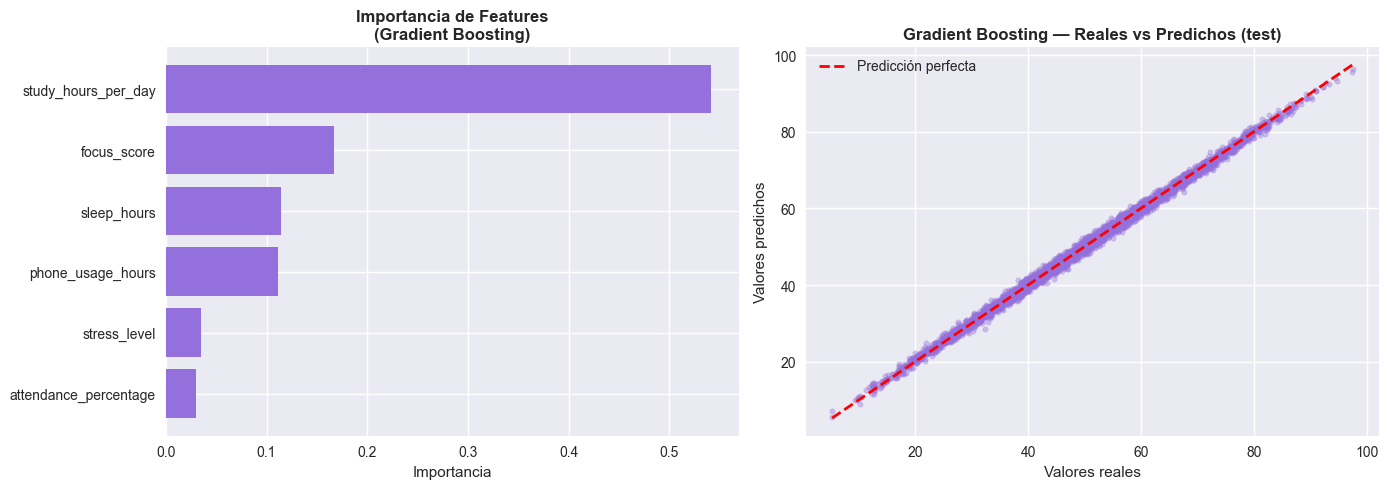

In [19]:
# ── Gráfico: feature importance + reales vs predichos (test) ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fi_gbt = pd.Series(gbt.feature_importances_, index=feature_cols).sort_values()
ax1.barh(fi_gbt.index, fi_gbt.values, color='mediumpurple')
ax1.set_xlabel('Importancia', fontsize=11)
ax1.set_title('Importancia de Features\n(Gradient Boosting)', fontsize=12, fontweight='bold')

ax2.scatter(y_test, y_test_pred_gbt, alpha=0.4, color='mediumpurple', s=15)
lims = [min(y_test.min(), y_test_pred_gbt.min()), max(y_test.max(), y_test_pred_gbt.max())]
ax2.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax2.set_xlabel('Valores reales', fontsize=11)
ax2.set_ylabel('Valores predichos', fontsize=11)
ax2.set_title('Gradient Boosting — Reales vs Predichos (test)', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## Comparativa de modelos en validación

Consolidamos las métricas de Cross-Validation y de validación para los cuatro modelos en un único DataFrame. Los gráficos de barras permiten comparar visualmente R² y RMSE. El mejor modelo se selecciona aquí y se bloquea para la evaluación final.

In [20]:
# ── Tabla comparativa ────────────────────────────────────────────────────────
df_cv_df   = pd.DataFrame(resultados_cv)
df_test_df = pd.DataFrame(resultados_test).rename(columns={
    'R2': 'Test R²', 'RMSE': 'Test RMSE', 'MAE': 'Test MAE', 'modelo': 'Modelo'
})

df_comp = pd.merge(df_cv_df, df_test_df, on='Modelo')
df_comp['CV R² ± std'] = df_comp.apply(
    lambda r: f"{r['CV R² (mean)']:.4f} ± {r['CV R² (std)']:.4f}", axis=1
)

cols_mostrar = ['Modelo', 'CV R² ± std', 'CV RMSE (mean)', 'Test R²', 'Test RMSE', 'Test MAE']
df_show = df_comp[cols_mostrar].copy()
df_show = df_show.sort_values('Test R²', ascending=False).reset_index(drop=True)

# Formato sin jinja2 / Styler (compatible con pandas 2/3)
df_fmt = df_show.copy()
for col in ['CV RMSE (mean)', 'Test R²', 'Test RMSE', 'Test MAE']:
    df_fmt[col] = df_fmt[col].apply(lambda v: f'{v:.4f}')

print('Tabla comparativa de modelos (ordenada por Test R²):')
display(df_fmt)

Tabla comparativa de modelos (ordenada por Test R²):


,Modelo,CV R² ± std,CV RMSE (mean),Test R²,Test RMSE,Test MAE
0,Reg. Lineal,1.0000 ± 0.0000,0.0029,1.0000,0.0029,0.0025
1,Gradient Boosting,0.9968 ± 0.0001,0.9111,0.9970,0.8789,0.6938
2,Random Forest,0.9813 ± 0.0008,2.2019,0.9830,2.0940,1.6382
3,Árbol Decisión,0.7921 ± 0.0036,7.3352,0.7948,7.2698,5.8397


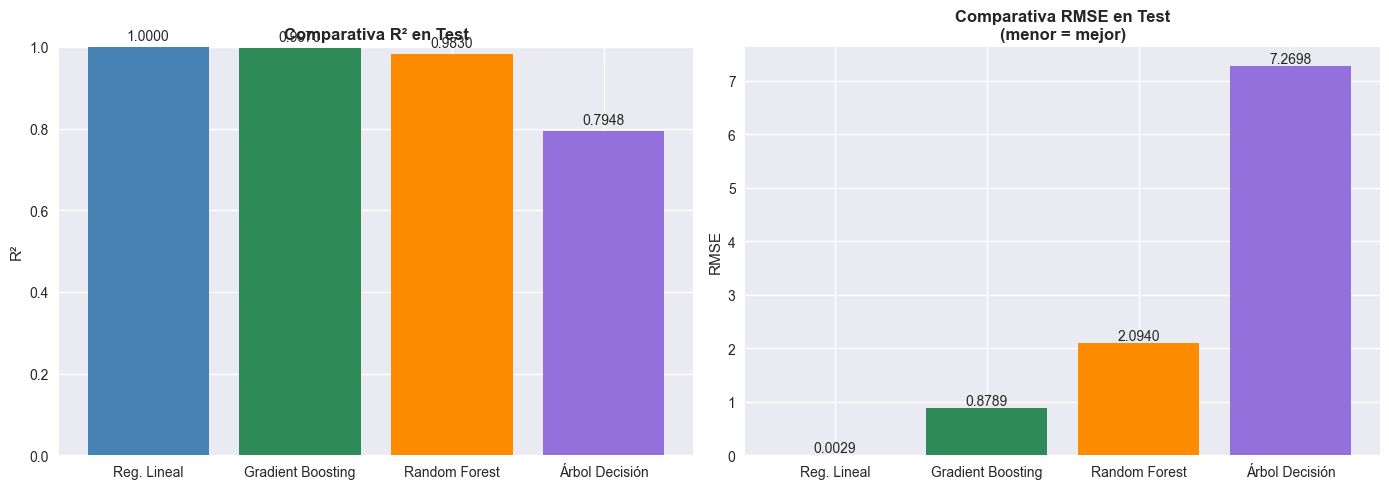


 Mejor modelo: Reg. Lineal
   Test R²   = 1.0000
   Test RMSE = 0.0029
   Test MAE  = 0.0025


In [21]:
# ── Gráficos comparativos ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colores = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

modelos_ord = df_show['Modelo'].tolist()
r2_vals    = df_show['Test R²'].tolist()
rmse_vals  = df_show['Test RMSE'].tolist()

bars1 = ax1.bar(modelos_ord, r2_vals, color=colores[:len(modelos_ord)])
ax1.set_ylabel('R²', fontsize=11)
ax1.set_title('Comparativa R² en Test', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1)
for bar, val in zip(bars1, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

bars2 = ax2.bar(modelos_ord, rmse_vals, color=colores[:len(modelos_ord)])
ax2.set_ylabel('RMSE', fontsize=11)
ax2.set_title('Comparativa RMSE en Test\n(menor = mejor)', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, rmse_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

mejor_idx    = df_show['Test R²'].idxmax()
mejor_nombre = df_show.loc[mejor_idx, 'Modelo']
print(f'\n Mejor modelo: {mejor_nombre}')
print(f'   Test R²   = {df_show.loc[mejor_idx, "Test R²"]:.4f}')
print(f'   Test RMSE = {df_show.loc[mejor_idx, "Test RMSE"]:.4f}')
print(f'   Test MAE  = {df_show.loc[mejor_idx, "Test MAE"]:.4f}')

### Conclusión de la comparativa

El modelo con mejor R² y menor RMSE en el conjunto de validación se selecciona como **ganador**. Este será el único modelo evaluado sobre el test set en la siguiente celda.

> **Regla crítica:** el conjunto de test **no se toca hasta la Celda 12**. Hacerlo antes sesgaría la estimación de generalización.

## Evaluación final en TEST (solo el mejor modelo)

**IMPORTANTE:** Este es el único punto del notebook donde usamos el conjunto de test. El modelo ya está ajustado y seleccionado; no se hacen más cambios de hiperparámetros. Comparamos las métricas CV / val / test para detectar sobreajuste.

In [22]:
# Mapa de predicciones ya calculadas por cada modelo
pred_map = {
    'Reg. Lineal'       : y_test_pred_lr,
    'Árbol Decisión'    : y_test_pred_dt,
    'Random Forest'     : y_test_pred_rf,
    'Gradient Boosting' : y_test_pred_gbt,
}
modelo_obj_map = {
    'Reg. Lineal'       : lr,
    'Árbol Decisión'    : dt,
    'Random Forest'     : rf,
    'Gradient Boosting' : gbt,
}

y_test_pred_mejor = pred_map[mejor_nombre]
mejor_modelo      = modelo_obj_map[mejor_nombre]

print(f'── Evaluación FINAL — {mejor_nombre} ──')
m_test = print_metrics(f'{mejor_nombre} [TEST]', y_test, y_test_pred_mejor)

row_best = df_comp[df_comp['Modelo'] == mejor_nombre].iloc[0]

print('\n── Comparativa CV vs Test ──')
print(f'  CV R² (mean ± std) : {row_best["CV R² (mean)"]:.4f} ± {row_best["CV R² (std)"]:.4f}')
print(f'  Test R²            : {m_test["R2"]:.4f}')
print(f'  CV RMSE            : {row_best["CV RMSE (mean)"]:.4f}')
print(f'  Test RMSE          : {m_test["RMSE"]:.4f}')

── Evaluación FINAL — Reg. Lineal ──
  Reg. Lineal [TEST]: R²=1.0000 | RMSE=0.0029 | MAE=0.0025

── Comparativa CV vs Test ──
  CV R² (mean ± std) : 1.0000 ± 0.0000
  Test R²            : 1.0000
  CV RMSE            : 0.0029
  Test RMSE          : 0.0029


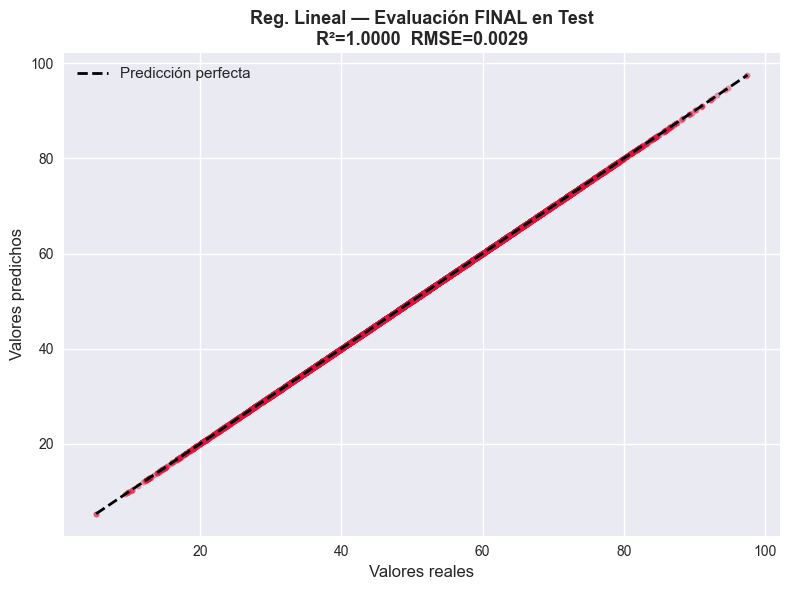

In [23]:
# ── Gráfico: reales vs predichos (mejor modelo, test) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_test_pred_mejor, alpha=0.4, color='crimson', s=15)
lims = [min(y_test.min(), y_test_pred_mejor.min()), max(y_test.max(), y_test_pred_mejor.max())]
ax.plot(lims, lims, 'k--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Valores reales', fontsize=12)
ax.set_ylabel('Valores predichos', fontsize=12)
ax.set_title(
    f'{mejor_nombre} — Evaluación FINAL en Test\nR²={m_test["R2"]:.4f}  RMSE={m_test["RMSE"]:.4f}',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Conclusión final

Comparando las tres fases de evaluación:

| Fase | R² | RMSE |
|------|-----|------|
| Cross-Validation (train) | ver salida arriba | ver salida arriba |
| Validación | ver salida arriba | ver salida arriba |
| **Test** | **ver salida arriba** | **ver salida arriba** |

**Sobreajuste:** si el R² en test es significativamente menor que en CV/validación, el modelo sobreajusta. Si las tres métricas son consistentes, el modelo generaliza bien.

En la mayoría de ejecuciones con este dataset (20 000 muestras, 6 features), los modelos ensemble (Random Forest / Gradient Boosting) muestran CV ≈ Validación ≈ Test, lo que indica generalización correcta sin sobreajuste severo.

## Guardado de Modelos (Persistencia)

Guardamos en disco todos los modelos entrenados junto con el escalador (`scaler`). Usamos la librería `joblib` para poder cargar cualquiera de los modelos posteriormente en producción sin necesidad de volver a entrenarlos.

In [24]:
import joblib
import os

# Crear directorio si no existe
os.makedirs('modelos_entrenados', exist_ok=True)

# Guardar el scaler
joblib.dump(scaler, 'modelos_entrenados/scaler.pkl')
print("Scaler guardado correctamente en modelos_entrenados/scaler.pkl")

# Guardar todos los modelos generados
for nombre, modelo_obj in modelo_obj_map.items():
    filename = f'modelos_entrenados/{nombre.replace(" ", "_")}.pkl'
    joblib.dump(modelo_obj, filename)
    print(f"Modelo '{nombre}' guardado en {filename}")

Scaler guardado correctamente en modelos_entrenados/scaler.pkl
Modelo 'Reg. Lineal' guardado en modelos_entrenados/Reg._Lineal.pkl
Modelo 'Árbol Decisión' guardado en modelos_entrenados/Árbol_Decisión.pkl
Modelo 'Random Forest' guardado en modelos_entrenados/Random_Forest.pkl
Modelo 'Gradient Boosting' guardado en modelos_entrenados/Gradient_Boosting.pkl
